In [7]:
#@title 📦 Kaggle Competition Loader { display-mode: "form" }
#@markdown ---
#@markdown ### How to use
#@markdown 1. In Colab, add **two** secrets via the 🔑 Secrets panel (left sidebar):
#@markdown    - `KAGGLE_USERNAME` → your Kaggle username
#@markdown    - `KAGGLE_KEY` → your Kaggle API key
#@markdown    Toggle "Notebook access" on for both.
#@markdown 2. Run this cell (code stays hidden — double-click the title to peek).
#@markdown 3. When prompted, paste the **full Kaggle competition URL**
#@markdown    (e.g. `https://www.kaggle.com/c/titanic`) — or just the slug.
#@markdown 4. After it finishes, your data is available as:
#@markdown    - `data['train.csv']`, `data['test.csv']`, etc. → pandas DataFrames
#@markdown    - `data['some_file.ext']` → file path (non-CSV files)
#@markdown    - `data_dir` → the local folder containing everything
#@markdown ---

import os
import re
import shutil
import kagglehub
import pandas as pd


def _authenticate_kaggle():
    try:
        from google.colab import userdata
    except ImportError:
        return

    def _get(name):
        try:
            v = userdata.get(name)
            return v.strip() if v else None
        except Exception:
            return None

    # Clear anything stale from earlier runs
    for k in ("KAGGLE_LEGACY_KEY", "KAGGLE_USERNAME", "KAGGLE_KEY"):
        os.environ.pop(k, None)

    token = _get("KAGGLE_API_TOKEN")      # your KGAT_... token
    legacy_key = _get("KAGGLE_LEGACY_KEY")
    username = _get("KAGGLE_USERNAME")

    if token:
        os.environ["KAGGLE_API_TOKEN"] = token
        print("Auth: using KAGGLE_API_TOKEN")
    elif username and legacy_key:
        os.environ["KAGGLE_USERNAME"] = username
        os.environ["KAGGLE_KEY"] = legacy_key
        print("Auth: using legacy username + key")
    else:
        raise RuntimeError(
            "Add either KAGGLE_API_TOKEN (KGAT_...) or "
            "KAGGLE_USERNAME + KAGGLE_LEGACY_KEY to Colab secrets, "
            "with Notebook access on."
        )


def _parse_kaggle_ref(text: str):
    """
    Determines whether the input points to a Kaggle *dataset* or
    *competition*, and extracts the identifier kagglehub needs.

    Returns:
        (kind, ref) where kind is 'dataset' or 'competition', and ref is
        either "owner/dataset-slug" (datasets) or "comp-slug" (competitions).
    """
    text = text.strip().rstrip('/')

    # Full dataset URL: kaggle.com/datasets/<owner>/<slug>
    match = re.search(r'kaggle\.com/datasets/([^/?#]+)/([^/?#]+)', text)
    if match:
        return 'dataset', f"{match.group(1)}/{match.group(2)}"

    # Full competition URL: kaggle.com/c/<slug> or kaggle.com/competitions/<slug>
    match = re.search(r'kaggle\.com/(?:c|competitions)/([^/?#]+)', text)
    if match:
        return 'competition', match.group(1)

    # Any other kaggle.com URL shape — can't reliably classify it
    if "kaggle.com" in text:
        return None, text.split('/')[-1]

    # Bare input, no domain: "owner/slug" implies a dataset handle;
    # a single token is treated as a competition slug.
    if '/' in text:
        return 'dataset', text
    return 'competition', text


def fetch_kaggle_competition(comp_url: str = None, copy_to_local: bool = True):
    """
    Downloads a Kaggle dataset or competition via kagglehub and loads all CSVs.

    Args:
        comp_url: Full Kaggle dataset/competition URL, or a slug
            ("comp-slug" for a competition, "owner/dataset-slug" for a
            dataset). If None, you'll be prompted.
        copy_to_local: If True, copies files out of the kagglehub cache into
            a local folder named after the slug.

    Returns:
        data: dict mapping filename -> DataFrame (for .csv) or filepath (other files)
        working_path: directory containing the dataset files
    """
    comp_input = comp_url or input("Paste Kaggle dataset/competition URL (or slug): ").strip()
    kind, comp_id = _parse_kaggle_ref(comp_input)

    if not comp_id:
        raise ValueError("Could not parse a dataset/competition identifier from that input.")
    if kind is None:
        raise ValueError(
            f"Couldn't tell whether '{comp_input}' is a dataset or a competition. "
            "Paste the full URL (kaggle.com/datasets/... or kaggle.com/c/...) "
            "or a bare slug (owner/dataset-slug, or comp-slug)."
        )

    print(f"\n[1/3] Authenticating & downloading {kind}: '{comp_id}'...")
    _authenticate_kaggle()
    try:
        if kind == 'dataset':
            cache_path = kagglehub.dataset_download(comp_id)
        else:
            cache_path = kagglehub.competition_download(comp_id)
    except Exception as e:
        if kind == 'competition':
            raise RuntimeError(
                f"Failed to download competition '{comp_id}'. If this is a 403, "
                f"make sure you've accepted the competition rules at "
                f"https://kaggle.com/competitions/{comp_id}/rules"
            ) from e
        raise RuntimeError(
            f"Failed to download dataset '{comp_id}'. Double-check the "
            "owner/slug is correct and the dataset is public (or you have access)."
        ) from e

    local_name = comp_id.replace('/', '_')
    target_dir = os.path.join(os.getcwd(), local_name)
    if copy_to_local:
        if os.path.exists(target_dir):
            shutil.rmtree(target_dir)
        shutil.copytree(cache_path, target_dir)
        working_path = target_dir
    else:
        working_path = cache_path

    print(f"[2/3] Files localized to: {working_path}")

    data = {}
    print("\n[3/3] Inspecting dataset contents:")
    for root, _, filenames in os.walk(working_path):
        for fname in sorted(filenames):
            fpath = os.path.join(root, fname)
            if fname.endswith('.csv'):
                data[fname] = pd.read_csv(fpath)
                print(f"  • {fname:30s} shape={data[fname].shape} -> data['{fname}']")
            else:
                data[fname] = fpath
                print(f"  • {fname:30s} (path saved) -> data['{fname}']")

    return data, working_path


# ==========================================
# RUN — paste your competition URL when asked
# ==========================================
data, data_dir = fetch_kaggle_competition()
print("\nAvailable keys:", list(data.keys()))

Paste Kaggle dataset/competition URL (or slug): https://www.kaggle.com/competitions/playground-series-s6e9

[1/3] Authenticating & downloading competition: 'playground-series-s6e9'...
Auth: using legacy username + key


100%|██████████| 14.1M/14.1M [00:00<00:00, 15.1MB/s]

Extracting files...


[2/3] Files localized to: /content/playground-series-s6e9

[3/3] Inspecting dataset contents:
  • sample_submission.csv          shape=(286571, 2) -> data['sample_submission.csv']
  • test.csv                       shape=(286571, 14) -> data['test.csv']
  • train.csv                      shape=(668665, 15) -> data['train.csv']

Available keys: ['sample_submission.csv', 'test.csv', 'train.csv']


# 0: setup


In [11]:
import numpy as np, pandas as pd

train = data['train.csv']
test  = data['test.csv']

target = [c for c in train.columns if c not in test.columns][0]
print("Target:", target)
print("Unique values:", train[target].nunique())   # must be 2

Target: Will_Buy_EV
Unique values: 2


# Load and explore

## Target and features

In [12]:
import numpy as np, pandas as pd

target = [c for c in train.columns if c not in test.columns][0]
features = [c for c in train.columns if c not in (target, 'id')]

print("Target  :", target)
print("Features:", features)
print("Shape   :", train.shape)

Target  : Will_Buy_EV
Features: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
Shape   : (668665, 15)


## Explore

In [13]:
print(train.dtypes)
print(train[target].value_counts(normalize=True))
train.describe(include='all').T.head(20)

id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       object
Current_Car_Type                object
Home_Charging_Possible          object
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                     object
dtype: object
Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,668665.0,NaN,NaN,NaN,334332.0,193027.10321,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,NaN,NaN,NaN,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,NaN,NaN,NaN,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,NaN,NaN,NaN,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,NaN,NaN,NaN,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,NaN,NaN,NaN,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,NaN,NaN,NaN,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,NaN,NaN,NaN,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0
Gender,668665,3,Male,367954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Type,668665,3,Urban,289305,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Sample for speed

In [14]:
from sklearn.model_selection import train_test_split

df, _ = train_test_split(train, train_size=100_000, stratify=train[target], random_state=42)
print(df.shape)

(100000, 15)


# Preprocessing
## Missing values

In [15]:
print(df.isnull().sum()[df.isnull().sum() > 0])   # empty output = no missing values

for col in features:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])   # categorical -> mode
    else:
        df[col] = df[col].fillna(df[col].median())    # numeric -> median

Series([], dtype: int64)


## Encode categoricals and target

In [16]:
y = df[target]
if y.dtype == 'object':
    y = y.astype('category').cat.codes          # text labels -> 0/1

X = pd.get_dummies(df[features], drop_first=True)
print(X.shape)

(100000, 18)


# Train/test split
## 80/20 split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)

(80000, 18) (20000, 18)


# Random Forest

## Train with hyperparameters

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=10,            # max depth of each tree
    min_samples_split=10,    # min samples needed to split a node
    random_state=42,
    n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=10, n_jobs=-1,
                       random_state=42)

## See what was learned

In [19]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.head(10))
print("Trees:", len(rf.estimators_), "| Depth of first tree:", rf.estimators_[0].get_depth())

Environmental_Concern_Level    0.526657
Subsidy_Available_Yes          0.273044
Annual_Income_USD              0.119334
Range_Anxiety_Level_Low        0.016775
Range_Anxiety_Level_Medium     0.014447
Daily_Commute_km               0.013465
Age                            0.009756
Charging_Stations_Near_Work    0.006608
Charging_Stations_Near_Home    0.005766
Home_Charging_Possible_Yes     0.004412
dtype: float64
Trees: 100 | Depth of first tree: 10


# Predictions and evaluation

## Predict on the test set

In [20]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

## Confusion matrix

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

[[15780   727]
 [ 1298  2195]]
TN=15780  FP=727  FN=1298  TP=2195


## Metrics

$$\text{Specificity}=\frac{TN}{TN+FP}$$

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

test_scores = {
    'Accuracy':    accuracy_score(y_test, y_pred),
    'Precision':   precision_score(y_test, y_pred),
    'Recall':      recall_score(y_test, y_pred),
    'Specificity': tn / (tn + fp),
    'F1-score':    f1_score(y_test, y_pred),
    'ROC-AUC':     roc_auc_score(y_test, y_proba),
}
for k, v in test_scores.items():
    print(f"{k:12s}: {v:.4f}")

Accuracy    : 0.8988
Precision   : 0.7512
Recall      : 0.6284
Specificity : 0.9560
F1-score    : 0.6843
ROC-AUC     : 0.9397


# Cross-validation (training data only)

## 5-Fold CV

In [23]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

kf_scores = cross_val_score(rf, X_train, y_train,
                            cv=KFold(5, shuffle=True, random_state=42),
                            scoring='accuracy', n_jobs=1)
print(kf_scores)
print(f"Mean={kf_scores.mean():.4f}  Std={kf_scores.std():.4f}")

[0.892875  0.889375  0.895625  0.897375  0.8933125]
Mean=0.8937  Std=0.0027


## Stratified K-Fold CV

In [24]:
skf_scores = cross_val_score(rf, X_train, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='accuracy', n_jobs=1)
print(skf_scores)
print(f"Mean={skf_scores.mean():.4f}  Std={skf_scores.std():.4f}")

[0.8931875 0.8938125 0.895875  0.89275   0.89325  ]
Mean=0.8938  Std=0.0011


## Compare CV vs test

In [25]:
compare = pd.DataFrame({
    'Mean accuracy': [kf_scores.mean(), skf_scores.mean(), test_scores['Accuracy']],
    'Std':           [kf_scores.std(),  skf_scores.std(),  np.nan],
}, index=['5-Fold CV', 'Stratified CV', 'Test set'])
print(compare.round(4))

               Mean accuracy     Std
5-Fold CV             0.8937  0.0027
Stratified CV         0.8938  0.0011
Test set              0.8988     NaN


# submission prep
## Preprocess the full train and test data together

In [26]:
n = len(train)
features = [c for c in train.columns if c not in (target, 'id')]

# fill values come from TRAIN only
fill = {c: (train[c].mode()[0] if train[c].dtype == 'object' else train[c].median())
        for c in features}

# encode train + test together so the dummy columns match exactly
all_X = pd.get_dummies(
    pd.concat([train[features], test[features]]).fillna(fill),
    drop_first=True)

X_full, X_sub = all_X.iloc[:n], all_X.iloc[n:]
print(X_full.shape, X_sub.shape)

(668665, 18) (286571, 18)


## Encode the target and remember the original labels

In [27]:
classes = sorted(train[target].unique())                 # original labels
y_full = train[target].map({c: i for i, c in enumerate(classes)})
print(classes)

['No', 'Yes']


## Refit the final model on all training data
*This takes a few minutes on 668k rows.*

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=10,
    random_state=42, n_jobs=-1)
rf_final.fit(X_full, y_full)

RandomForestClassifier(max_depth=10, min_samples_split=10, n_jobs=-1,
                       random_state=42)

## Check what the competition expects

In [33]:
sample = data['sample_submission.csv']
id_col, pred_col = sample.columns

print(sample.dtypes)
print(sample.head())
print("Classes:", classes)   # index 1 is what predict_proba[:, 1] refers to

id               int64
Will_Buy_EV    float64
dtype: object
       id  Will_Buy_EV
0  668665     0.174645
1  668666     0.174645
2  668667     0.174645
3  668668     0.174645
4  668669     0.174645
Classes: ['No', 'Yes']


## Predict on the competition test set

In [34]:
USE_PROBA = True     # True if sample values are floats, False if ints (0/1)

if USE_PROBA:
    preds = rf_final.predict_proba(X_sub)[:, 1].astype(float)   # P(class = classes[1])
else:
    preds = rf_final.predict(X_sub).astype(int)                 # 0/1 codes

print(preds[:5], preds.dtype)

[0.02294233 0.05390274 0.02605843 0.02298227 0.10003082] float64


## Build and validate the submission file

In [35]:
sub = pd.DataFrame({id_col: test[id_col].values, pred_col: preds})

assert sub.shape == sample.shape
assert (sub[id_col].values == sample[id_col].values).all()
assert sub[pred_col].dtype != object, "still text!"

sub.to_csv('submission_file.csv', index=False)
sub.head()

,id,Will_Buy_EV
0,668665,0.022942
1,668666,0.053903
2,668667,0.026058
3,668668,0.022982
4,668669,0.100031


In [36]:
#@title Submit predictions to Kaggle { display-mode: "form" }
#@markdown Reads Kaggle credentials from Colab secrets, validates each
#@markdown `submission_*.csv` against `sample_submission.csv`, then asks
#@markdown for a per-file y/n confirmation before submitting.
#@markdown
#@markdown ⚠️ **Most Kaggle competitions cap you at 5 submissions/day.**
#@markdown Check the "My Submissions" tab on the competition page for
#@markdown your remaining count before confirming each file — a 400/403
#@markdown error with no other obvious cause usually means you hit the cap.
#@markdown
#@markdown Assumes the Kaggle Competition Loader cell has already run
#@markdown (uses its `data` and `data_dir` globals).

from google.colab import userdata
import os, glob, pandas as pd

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_LEGACY_KEY')

COMP = os.path.basename(data_dir)   # slug taken from the loader cell, no re-entry needed
sample = data['sample_submission.csv']

for path in sorted(glob.glob("submission_*.csv")):
    sub = pd.read_csv(path)
    ok = (sub.shape == sample.shape
          and list(sub.columns) == list(sample.columns)
          and sub['id'].astype(int).equals(sample['id'].astype(int))
          and sub.isna().sum().sum() == 0)
    print(f"\n{path}: {'OK' if ok else 'MISMATCH'} — shape {sub.shape}, dtypes {dict(sub.dtypes)}")
    if not ok:
        print("  Skipping — fix the file before submitting.")
        continue
    if input(f"Submit {path}? (y/n): ").strip().lower() == 'y':
        msg = input("  Submission message: ").strip() or path
        os.system(f'kaggle competitions submit -c {COMP} -f {path} -m "{msg}"')


submission_file.csv: OK — shape (286571, 2), dtypes {'id': dtype('int64'), 'Will_Buy_EV': dtype('float64')}
Submit submission_file.csv? (y/n): y
  Submission message: comp_sub2


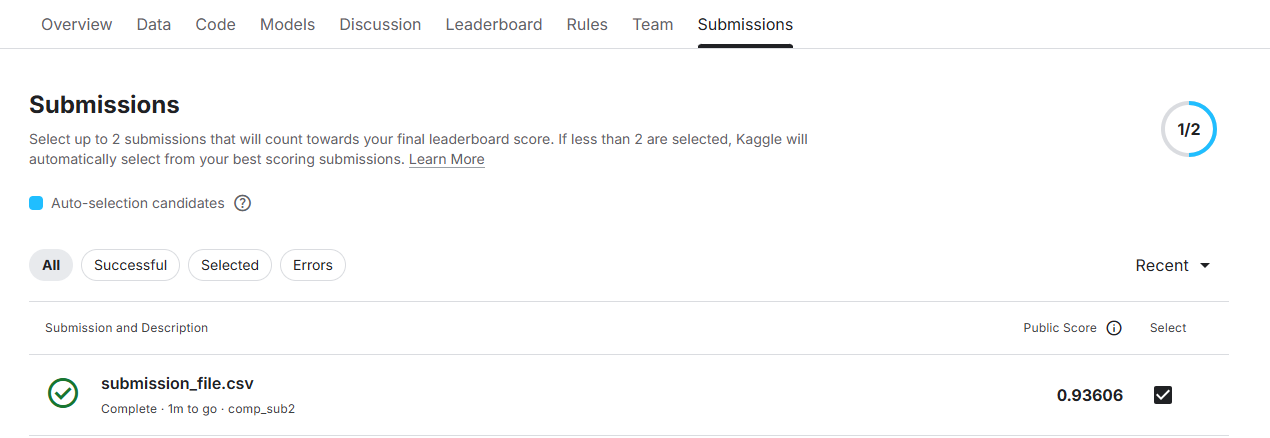

# in leaderboard

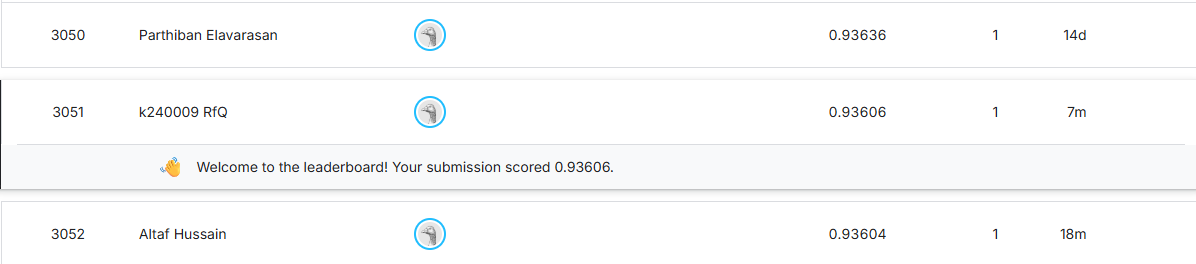